# Домашнее задание №10

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Задание 1

Подготовить тестовое изображение с одним объектом в градациях серого.

In [13]:
h, w = 380, 520
gray = np.full((h, w), 245, dtype=np.uint8)
center = (w // 2, h // 2)
axes = (140, 85)
cv2.ellipse(gray, center, axes, 25, 0, 360, 55, -1)

array([[245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       ...,
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245]], shape=(380, 520), dtype=uint8)

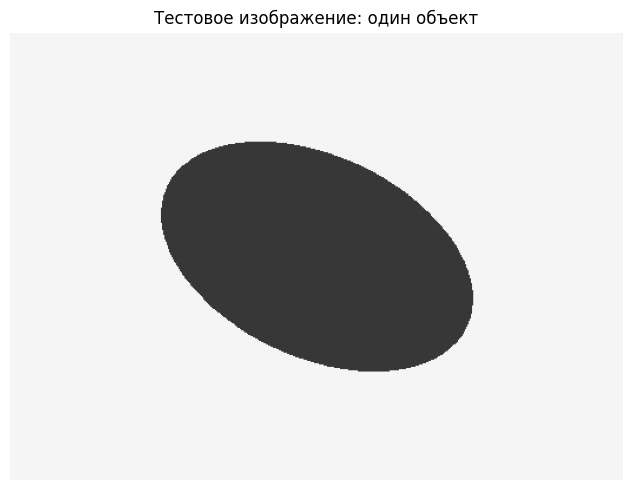

In [14]:
plt.figure(figsize=(7, 5))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("Тестовое изображение: один объект")
plt.tight_layout()
plt.show()

## Задание 2

Найти контур объекта.

In [15]:
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
contour = max(contours, key=cv2.contourArea)

## Задание 3

Вычислить координаты центроида (через моменты) и построить его на изображении контура.

In [16]:
M = cv2.moments(contour)
m00 = M["m00"]
cx = M["m10"] / m00
cy = M["m01"] / m00
centroid_img = np.zeros((h, w, 3), dtype=np.uint8)
cv2.drawContours(centroid_img, [contour], -1, (0, 255, 0), 2)
cv2.circle(centroid_img, (int(round(cx)), int(round(cy))), 6, (0, 0, 255), -1)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(380, 520, 3), dtype=uint8)

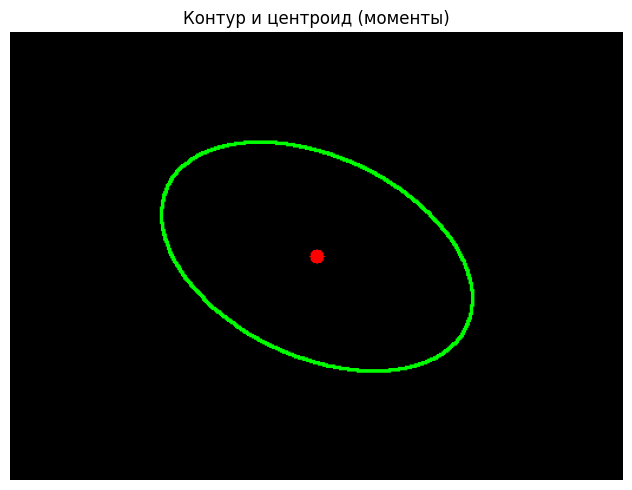

In [17]:
plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(centroid_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Контур и центроид (моменты)")
plt.tight_layout()
plt.show()

## Задание 4

Вычислить периметр контура (cv.arcLength).

In [18]:
perimeter = cv2.arcLength(contour, True)
print(f"Периметр контура: {perimeter}")

Периметр контура: 758.4234417676926


## Задание 5

Вычислить Фурье-дескрипторы для контура (numpy.fft.fft).

In [19]:
pts = contour[:, 0, :].astype(np.float64)
x = pts[:, 0]
y = pts[:, 1]
z = x + 1j * y
fourier_descriptors = np.fft.fft(z)
K = len(fourier_descriptors)
print(f"Число точек контура K = {K}")
print(f"Число коэффициентов Фурье: {len(fourier_descriptors)}")

Число точек контура K = 647
Число коэффициентов Фурье: 647


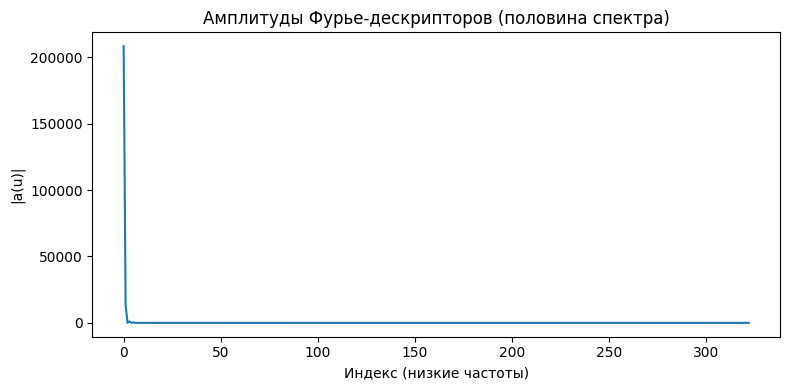

In [20]:
mag = np.abs(fourier_descriptors)
plt.figure(figsize=(8, 4))
plt.plot(mag[: K // 2])
plt.xlabel("Индекс (низкие частоты)")
plt.ylabel("|a(u)|")
plt.title("Амплитуды Фурье-дескрипторов (половина спектра)")
plt.tight_layout()
plt.show()

## Задание 6

Восстановить контур с помощью 10%, 5%, 1% дескрипторов (остальные занулить).

In [21]:
def reconstruct_contour(fd, percent):
    n_keep = max(1, int(round(len(fd) * percent / 100.0)))
    fd_cut = np.zeros_like(fd)
    fd_cut[:n_keep] = fd[:n_keep]
    z_rec = np.fft.ifft(fd_cut)
    xr = np.real(z_rec)
    yr = np.imag(z_rec)
    pts_rec = np.stack([xr, yr], axis=1).astype(np.float32)
    return pts_rec, n_keep


def polyline_to_bgr(poly):
    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    pp = np.round(poly).astype(np.int32)
    pp = pp.reshape(-1, 1, 2)
    cv2.polylines(canvas, [pp], isClosed=True, color=(0, 200, 255), thickness=2)
    return canvas


rec10, n10 = reconstruct_contour(fourier_descriptors, 10)
rec5, n5 = reconstruct_contour(fourier_descriptors, 5)
rec1, n1 = reconstruct_contour(fourier_descriptors, 1)
print(f"Сохранено коэффициентов: 10% -> {n10}, 5% -> {n5}, 1% -> {n1}")
img_rec10 = polyline_to_bgr(rec10)
img_rec5 = polyline_to_bgr(rec5)
img_rec1 = polyline_to_bgr(rec1)

Сохранено коэффициентов: 10% -> 65, 5% -> 32, 1% -> 6


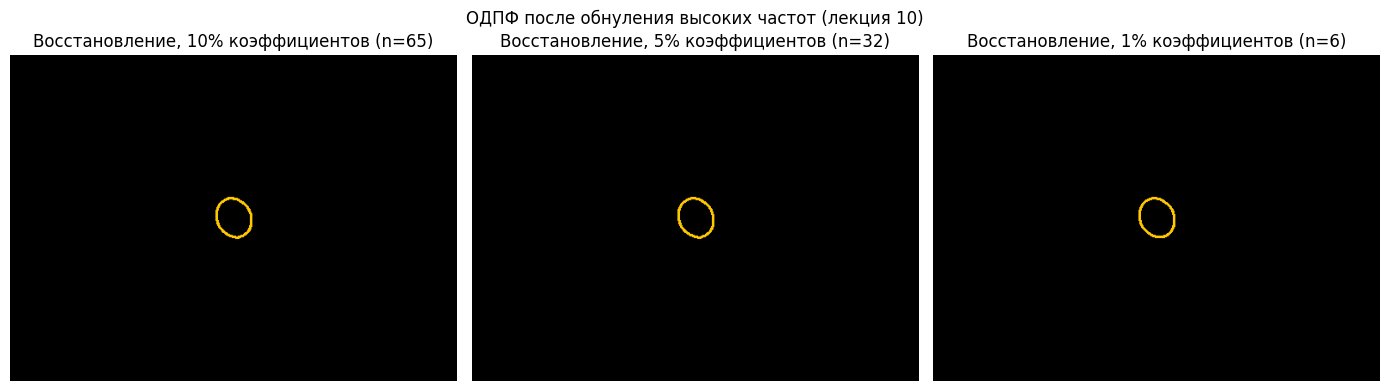

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = [
    f"Восстановление, 10% коэффициентов (n={n10})",
    f"Восстановление, 5% коэффициентов (n={n5})",
    f"Восстановление, 1% коэффициентов (n={n1})",
]
for ax, bgr, title in zip(axes, [img_rec10, img_rec5, img_rec1], titles):
    ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("ОДПФ после обнуления высоких частот (лекция 10)")
plt.tight_layout()
plt.show()

### Выполнил: Мелешенко Николай